In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
users = pd.read_csv('users.csv')
orders = pd.read_csv('orders.csv')

print(f"users表形状: {users.shape}")
print(f"orders表形状: {orders.shape}")
print("\nusers表前3行:")
print(users.head(3))
print("\norders表前3行:")
print(orders.head(3))
print("\nusers表数据类型:")
print(users.dtypes)
print("\norders表数据类型:")
print(orders.dtypes)
print("\nusers表缺失值数量:")
print(users.isna().sum())
print("\norders表缺失值数量:")
print(orders.isna().sum())

users表形状: (204, 5)
orders表形状: (800, 6)

users表前3行:
   user_id gender        city   age register_date
0    10128      M   hangzhou   -5.0    2025-11-19
1    10012    NaN   HANGZHOU   26.0    2025-11-24
2    10019      女         NaN  21.0    2025-09-13

orders表前3行:
   order_id  user_id   category      price  quantity        order_time
0    500016    10126     Beauty  22.990246       1.0  2025-10-02T11:48
1    500147    10091  Clothing   22.242999       5.0  2025-12-21T07:07
2    500542    10091   Clothing  34.870726       2.0  2025-11-18T05:04

users表数据类型:
user_id            int64
gender               str
city                 str
age              float64
register_date        str
dtype: object

orders表数据类型:
order_id        int64
user_id         int64
category          str
price         float64
quantity      float64
order_time        str
dtype: object

users表缺失值数量:
user_id           0
gender           27
city             26
age              24
register_date     0
dtype: int64

orders表缺失值数量

In [48]:
#users表处理缺失值age
#策略1：用中位数填充age缺失值
users_fill = users.copy()
age_median = users_fill['age'].median()
users_fill['age'] = users_fill['age'].fillna(age_median)

#策略2：删除age缺失的行
users_drop = users.copy()
users_drop.dropna(subset=['age'], inplace=True)

print(f"age中位数: {age_median}")
print(f"\n填充后users_fill缺失值情况:")
print(users_fill.isna().sum())
print(f"\n删除后users_drop缺失值情况:")
print(users_drop.isna().sum())
print(f"\nusers原表行数: {len(users)}")
print(f"users_fill行数: {len(users_fill)}")
print(f"users_drop行数: {len(users_drop)}")

age中位数: 22.0

填充后users_fill缺失值情况:
user_id           0
gender           27
city             26
age               0
register_date     0
dtype: int64

删除后users_drop缺失值情况:
user_id           0
gender           24
city             23
age               0
register_date     0
dtype: int64

users原表行数: 204
users_fill行数: 204
users_drop行数: 180


In [49]:
#orders表处理缺失值price,quantity
#按category分组填充price和quantity
orders_filled = orders.copy()
for category in orders_filled['category'].unique():
    mask = orders_filled['category'] == category

    price_median = orders_filled.loc[mask, 'price'].median()
    orders_filled.loc[mask, 'price'] = orders_filled.loc[mask, 'price'].fillna(price_median)

    quantity_median = orders_filled.loc[mask, 'quantity'].median()
    orders_filled.loc[mask, 'quantity'] = orders_filled.loc[mask, 'quantity'].fillna(quantity_median)

print(f"\n处理后缺失值数量:")
print(orders_filled.isna().sum())

#异常值清洗
orders_clean = orders_filled.copy()
price_anomaly_before = (orders_clean['price'] <= 0).sum()
quantity_anomaly_before = (orders_clean['quantity'] <= 0).sum()
print(f"清洗前异常值数量:price<=0: {price_anomaly_before}, quantity<=0: {quantity_anomaly_before}")

#将异常值设为缺失
orders_clean.loc[orders_clean['price'] <= 0, 'price'] = np.nan
orders_clean.loc[orders_clean['quantity'] <= 0, 'quantity'] = np.nan

# 重新填充
for category in orders_clean['category'].unique():
    mask = orders_clean['category'] == category

    price_median = orders_clean.loc[mask, 'price'].median()
    quantity_median = orders_clean.loc[mask, 'quantity'].median()

    orders_clean.loc[mask, 'price'] = orders_clean.loc[mask, 'price'].fillna(price_median)
    orders_clean.loc[mask, 'quantity'] = orders_clean.loc[mask, 'quantity'].fillna(quantity_median)

price_anomaly_after = (orders_clean['price'] <= 0).sum()
quantity_anomaly_after = (orders_clean['quantity'] <= 0).sum()

print(f"清洗后异常值数量:price<=0: {price_anomaly_after}, quantity<=0: {quantity_anomaly_after}")


处理后缺失值数量:
order_id      0
user_id       0
category      0
price         0
quantity      0
order_time    0
dtype: int64
清洗前异常值数量:price<=0: 10, quantity<=0: 10
清洗后异常值数量:price<=0: 0, quantity<=0: 0


In [50]:
#统一gender
print("gender处理前分布:")
print(users['gender'].value_counts(dropna=False))

users_processed = users_drop.copy()  #使用删除缺失值的版本
def unify_gender(g):
    if pd.isna(g) or g == '' or g == ' ':
        return 'Unknown'
    g = str(g).lower().strip()
    if g in ['m', 'male', '男']:
        return 'M'
    elif g in ['f', 'female', '女']:
        return 'F'
    else:
        return 'Unknown'

users_processed['gender'] = users_processed['gender'].apply(unify_gender)

print("\ngender处理后分布:")
print(users_processed['gender'].value_counts())

gender处理前分布:
gender
M         45
F         43
NaN       27
male      26
female    24
女         22
男         17
Name: count, dtype: int64

gender处理后分布:
gender
M          79
F          77
Unknown    24
Name: count, dtype: int64


In [51]:
#数据合并与增加派生特征
#合并数据
merged_df = pd.merge(orders_clean, users_processed, on='user_id', how='left')
print(f"合并后数据形状: {merged_df.shape}")

#检查找不到用户信息的订单
missing_user_info = merged_df['city'].isna() | merged_df['gender'].isna()
missing_count = missing_user_info.sum()
print(f"找不到用户信息的订单数: {missing_user_info}")

#增加派生特征
merged_df['total_price'] = merged_df['price'] * merged_df['quantity']
price_75_quantile = merged_df['total_price'].quantile(0.75)
merged_df['is_high_value'] = merged_df['total_price'] > price_75_quantile

print(f"\ntotal_price描述性统计:")
print(merged_df['total_price'].describe())
print(f"\n75%分位数: {price_75_quantile:.2f}")
print(f"高价值订单数量: {merged_df['is_high_value'].sum()}")

合并后数据形状: (814, 10)
找不到用户信息的订单数: 0      False
1      False
2      False
3       True
4       True
       ...  
809    False
810    False
811    False
812    False
813     True
Length: 814, dtype: bool

total_price描述性统计:
count    814.000000
mean      71.177351
std       61.411528
min        5.358296
25%       29.839709
50%       54.205057
75%       94.588007
max      645.851367
Name: total_price, dtype: float64

75%分位数: 94.59
高价值订单数量: 202


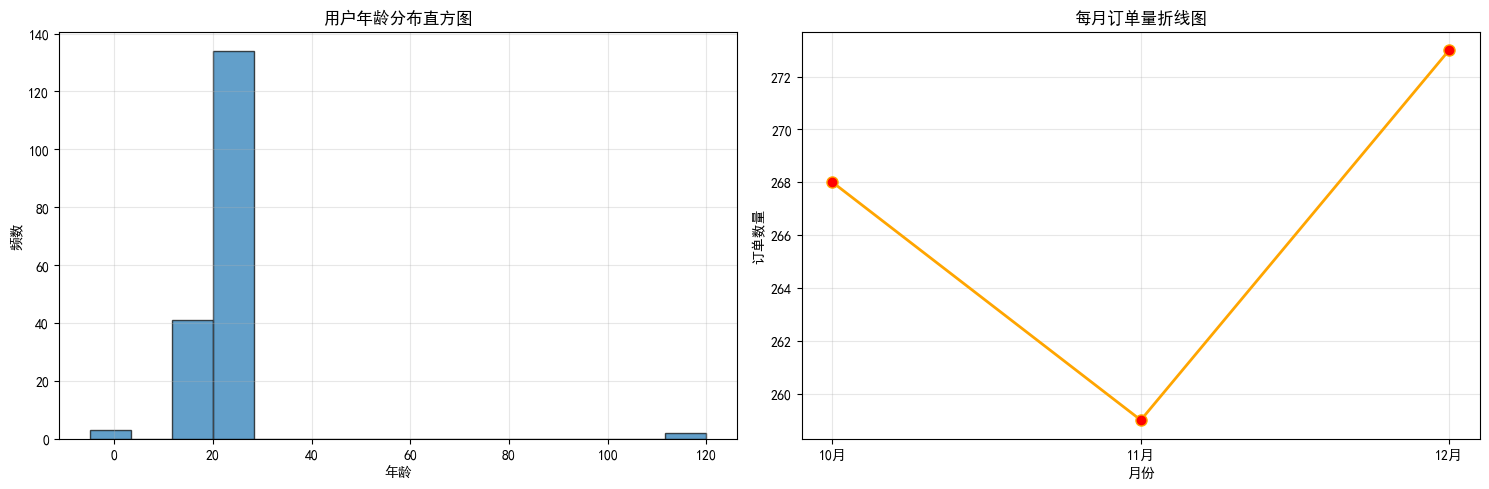

In [52]:
#数据可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#年龄分布直方图
axes[0].hist(users_processed['age'], bins=15, edgecolor='black', alpha=0.7)
axes[0].set_title('用户年龄分布直方图')
axes[0].set_xlabel('年龄')
axes[0].set_ylabel('频数')
axes[0].grid(True, alpha=0.3)

#每月订单量折线图
orders['order_time'] = pd.to_datetime(orders['order_time'])
monthly_orders = orders.set_index('order_time').resample('ME').size()

#生成月份标签（如 "10月", "11月", "12月"）
month_labels = [date.strftime('%m月') for date in monthly_orders.index]

axes[1].plot(month_labels, monthly_orders.values, marker='o', linewidth=2, markersize=8, color='orange', markerfacecolor='red')
axes[1].set_title('每月订单量折线图')
axes[1].set_xlabel('月份')
axes[1].set_ylabel('订单数量')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()